# 3주차 · Molecular Descriptor와 Conformer

각 Section에서 코드를 실행하고, **직접 SMILES를 바꿔보거나 하면서 진행하면 된다!**

> 어떤 한계를 가지는지를 **직접 코드를 돌려보고 구조 이미지와 비교하며** 확인하는 것이 이 실습의 목적이다.

새로운 도구 설치:

```bash
pip install py3Dmol termcolor
```

## Section 0 · 환경 확인 (W3-01)

In [83]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, SVG

from rdkit import Chem, rdBase
from rdkit.Chem import AllChem, Descriptors, Crippen, Draw
from rdkit.Chem import rdMolDescriptors, rdMolAlign, rdFingerprintGenerator, DataStructs
import py3Dmol
from termcolor import colored

print(f'Python: {sys.version}')
print(f'RDKit:  {rdBase.rdkitVersion}')
print(f'py3Dmol: {py3Dmol.__version__}')

Python: 3.13.12 | packaged by Anaconda, Inc. | (main, Feb 24 2026, 16:05:56) [MSC v.1942 64 bit (AMD64)]
RDKit:  2025.03.6
py3Dmol: 2.5.5


## [지난 주 복기] 분자를 비트로 표현하는 Fingerprint — Morgan vs AtomPair

**Fingerprint**는 분자의 부분 구조나 원자 쌍 거리를 0과 1의 비트 배열(Vector)로 표현한 것이다.  
지난 주에 했던 것처럼 **Morgan**과 **AtomPair**를 직접 계산하고 **구조 이미지와 비트를 함께 관찰**해보자.

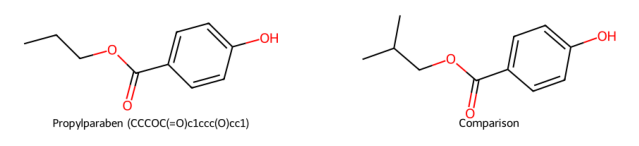

=== 1. Morgan Fingerprint (ECFP) — 반경(radius)에 따른 비트 변화 ===
   Morgan: 켜진 비트(on-bits) = 25개 / 2048
   처음 64비트: 0000000000000100000000000000000000000000000000000000000000000000
   Morgan: 켜진 비트(on-bits) = 26개 / 2048
   처음 64비트: 0100000000000000000000000000000000000000000000000000000000000000
두 분자의 Morgan(ECFP4) Fingerprint 유사도: 0.5938

=== 2. AtomPair Fingerprint — 원자 쌍과 최단 결합 거리 ===
   AtomPair (왼): 켜진 비트(on-bits) = 70개 / 2048
   처음 64비트 (왼): 1100100000000000000000000000000010000000000000000000000000000000
   AtomPair (우): 켜진 비트(on-bits) = 82개 / 2048
   처음 64비트 (우): 0000100000000000000000000000000010000000000000000000000000000000
두 분자의 AtomPair Fingerprint 유사도: 0.6703


In [84]:
# 1. 분자 구조 확인 및 Fingerprint 비트 생성
mol_example = Chem.MolFromSmiles('CCCOC(=O)c1ccc(O)cc1')  # Propylparaben

# 이쪽을 변경해보면서 차이를 확인해보자.
compare_smiles = 'CC(C)COC(=O)c1ccc(O)cc1'  # Ethylparaben
####################################

mol_compare = Chem.MolFromSmiles(compare_smiles)  

def remind_mol_image(mol1, mol2):
    # 이미지로 보여주기
    example_img = Draw.MolToImage(mol1, size=(400, 180), legend='Propylparaben (CCCOC(=O)c1ccc(O)cc1)')
    compare_img = Draw.MolToImage(mol2, size=(400, 180), legend='Comparison')

    # example과 compare를 좌우로 배치
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(example_img)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(compare_img)
    plt.axis('off')

    plt.show()
remind_mol_image(mol_example, mol_compare)

def remind_two_mol_bit_diff(mol1, mol2):
    # 두 분자의 Fingerprint를 생성
    gen_morgan = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
    fp1 = gen_morgan.GetFingerprint(mol1)
    fp2 = gen_morgan.GetFingerprint(mol2)

    print(colored('=== 1. Morgan Fingerprint (ECFP) — 반경(radius)에 따른 비트 변화 ===', 'white'))
    gen_morgan = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
    fp_morgan = gen_morgan.GetFingerprint(mol_example)
    print(colored(f'   Morgan: 켜진 비트(on-bits) = {fp_morgan.GetNumOnBits()}개 / 2048', 'green'))
    print(colored('   처음 64비트:', 'green'), fp_morgan.ToBitString()[:64])
    fp2_morgan = gen_morgan.GetFingerprint(mol_compare)
    print(colored(f'   Morgan: 켜진 비트(on-bits) = {fp2_morgan.GetNumOnBits()}개 / 2048', 'yellow'))
    print(colored('   처음 64비트:', 'yellow'), fp2_morgan.ToBitString()[:64])

    # 두 Fingerprint의 비트 차이를 계산
    bit_diff = DataStructs.FingerprintSimilarity(fp1, fp2)
    print(f'두 분자의 Morgan(ECFP4) Fingerprint 유사도: {bit_diff:.4f}')

    gen_ap = rdFingerprintGenerator.GetAtomPairGenerator(fpSize=2048)
    fp_ap1 = gen_ap.GetFingerprint(mol1)
    fp_ap2 = gen_ap.GetFingerprint(mol2)
    print(colored('\n=== 2. AtomPair Fingerprint — 원자 쌍과 최단 결합 거리 ===', 'white'))
    print(colored(f'   AtomPair (왼): 켜진 비트(on-bits) = {fp_ap1.GetNumOnBits()}개 / 2048', 'green'))
    print(colored('   처음 64비트 (왼):', 'green'), fp_ap1.ToBitString()[:64])
    print(colored(f'   AtomPair (우): 켜진 비트(on-bits) = {fp_ap2.GetNumOnBits()}개 / 2048', 'yellow'))
    print(colored('   처음 64비트 (우):', 'yellow'), fp_ap2.ToBitString()[:64])
    bit_diff_ap = DataStructs.FingerprintSimilarity(fp_ap1, fp_ap2)
    print(f'두 분자의 AtomPair Fingerprint 유사도: {bit_diff_ap:.4f}')
remind_two_mol_bit_diff(mol_example, mol_compare)

### Morgan 원형 환경을 이미지로 확인해보자

Morgan Fingerprint의 각 비트는 **중심 원자와 그 주변 반경(radius)의 부분 구조**를 의미한다.  
실제로 어떤 원자 주변 환경이 비트로 켜졌는지 시각화해보자.

r=반경

Propylparaben에서 켜진 Morgan 비트들의 원형 환경 시각화:


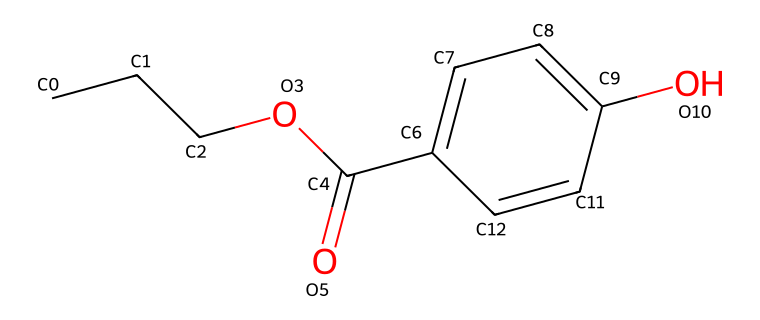

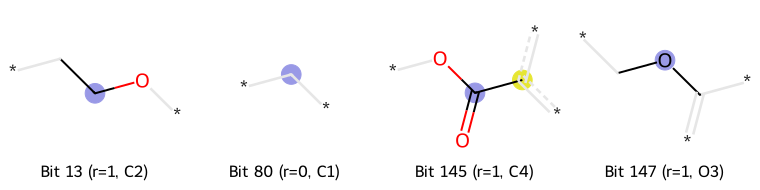

In [85]:
mol_example_morgan = Chem.MolFromSmiles('CCCOC(=O)c1ccc(O)cc1')  # Propylparaben

# Morgan Fingerprint의 켜진 비트가 나타내는 원자 주변 환경 시각화
def show_morgan_bits(mol, radius=2, num_bits=4):
    """분자에서 켜진 Morgan 비트들의 원자 원형 환경을 시각화한다."""

    # 먼저 전체 분자에서 RDKit의 원자 번호(0-based)를 확인한다.
    indexed_mol = Chem.Mol(mol)
    for atom in indexed_mol.GetAtoms():
        atom.SetProp("atomNote", f"{atom.GetSymbol()}{atom.GetIdx()}")

    atom_index_image = Draw.MolToImage(indexed_mol, size=(760, 320))
    display(atom_index_image)

    # 비트별 중심 원자와 radius 정보를 수집하도록 설정
    additional_output = rdFingerprintGenerator.AdditionalOutput()
    additional_output.AllocateBitInfoMap()

    gen_morgan = rdFingerprintGenerator.GetMorganGenerator(
        radius=radius,
        fpSize=2048
    )

    fp = gen_morgan.GetFingerprint(
        mol,
        additionalOutput=additional_output
    )

    info = additional_output.GetBitInfoMap()

    chosen = []
    legends = []

    for bit, instances in list(info.items())[:num_bits]:
        atom_idx, bit_radius = instances[0]

        chosen.append((mol, bit, info))

        symbol = mol.GetAtomWithIdx(atom_idx).GetSymbol()
        legends.append(
            f"Bit {bit} (r={bit_radius}, {symbol}{atom_idx})"
        )

    if not chosen:
        print("시각화할 Morgan 비트 환경이 없습니다.")
        return

    image = Draw.DrawMorganBits(
        chosen,
        molsPerRow=len(chosen),
        legends=legends,
        subImgSize=(190, 190),
        useSVG=False
    )

    display(image)

print('Propylparaben에서 켜진 Morgan 비트들의 원형 환경 시각화:')
show_morgan_bits(mol_example_morgan, radius=2, num_bits=4)

### AtomPair 최단 결합 거리

AtomPair는 **분자 내 임의의 두 원자 쌍과 둘 사이의 최단 결합 거리(bonds)**를 기록한다.  
아래에서 시작, 도착 번호를 변경하면서 확인해보자.

전체 구조의 원자 번호 (RDKit 0-based indexing):


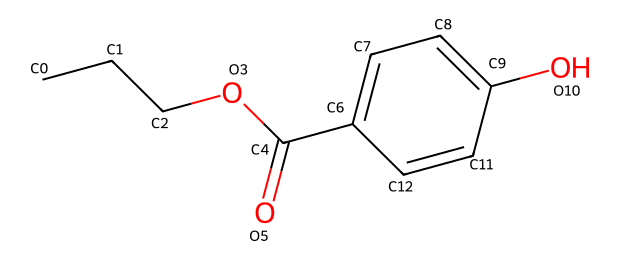

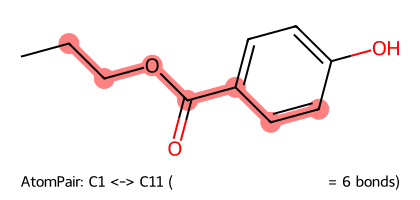

CC Pair


In [86]:
# AtomPair 최단 결합 경로 시각화 함수
def show_atom_pair_path(mol, idx1, idx2):
    """두 원자와 그 사이의 최단 결합 경로를 시각화하여 AtomPair 원리를 보여준다."""
    # 최단 경로를 보기 전에 전체 분자의 원자 번호를 확인한다.
    indexed_mol = Chem.Mol(mol)
    for atom in indexed_mol.GetAtoms():
        atom.SetProp("atomNote", f"{atom.GetSymbol()}{atom.GetIdx()}")

    print("전체 구조의 원자 번호 (RDKit 0-based indexing):")
    atom_index_image = Draw.MolToImage(indexed_mol, size=(620, 260))
    display(atom_index_image)

    path = Chem.GetShortestPath(mol, idx1, idx2)
    bonds = [mol.GetBondBetweenAtoms(path[i], path[i+1]).GetIdx() for i in range(len(path)-1)]
    a1 = mol.GetAtomWithIdx(idx1).GetSymbol()
    a2 = mol.GetAtomWithIdx(idx2).GetSymbol()
    dist = len(path) - 1
    legend = f'AtomPair: {a1}{idx1} <-> {a2}{idx2} (최단 거리 = {dist} bonds)'
    display(Draw.MolToImage(mol, highlightAtoms=path, highlightBonds=bonds, size=(420, 200), legend=legend))
    print(f'{a1}{a2} Pair')

mol_example_atompair = Chem.MolFromSmiles('CCCOC(=O)c1ccc(O)cc1')
start_atom_idx = 1
end_atom_idx = 11
show_atom_pair_path(mol_example_atompair, start_atom_idx, end_atom_idx)

> 이제 다시 강의 자료를 확인해보자

## Section 1 · Molecular Descriptor

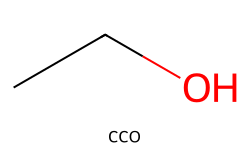

MolWt:     46.069
MolLogP:   -0.0014
TPSA:      20.23
HBD:       1
HBA:       1
RotBonds:  0


In [87]:
smiles = 'CCO'  # 에탄올

mol = Chem.MolFromSmiles(smiles)

def calculate_and_display_descriptors(mol, smiles):
    display(Draw.MolToImage(mol, size=(250, 150), legend=f'{smiles}'))
    print('MolWt:    ', round(Descriptors.MolWt(mol), 3))
    print('MolLogP:  ', round(Crippen.MolLogP(mol), 4))
    print('TPSA:     ', round(Descriptors.TPSA(mol), 2))
    print('HBD:      ', Descriptors.NumHDonors(mol))
    print('HBA:      ', Descriptors.NumHAcceptors(mol))
    print('RotBonds: ', Descriptors.NumRotatableBonds(mol))

calculate_and_display_descriptors(mol, smiles)

### 📝 관찰 기록

| Descriptor | 에탄올 (CCO) | 1-부탄올 (CCCCO) | 변했는가? |
|---|---|---|---|
| MolWt | | | |
| MolLogP | | | |
| TPSA | | | |
| HBD | | | |

> **TPSA가 20.23으로 동일하다.** 탄소 사슬이 길어져도 극성 부분(OH)이 같기 때문이다.  
> 이처럼 각 descriptor는 분자의 **서로 다른 측면**을 본다.

## Section 2 · 여러 분자의 Descriptor 표 (특히 독성학에서 LogP와 TPSA가 핵심인 이유)

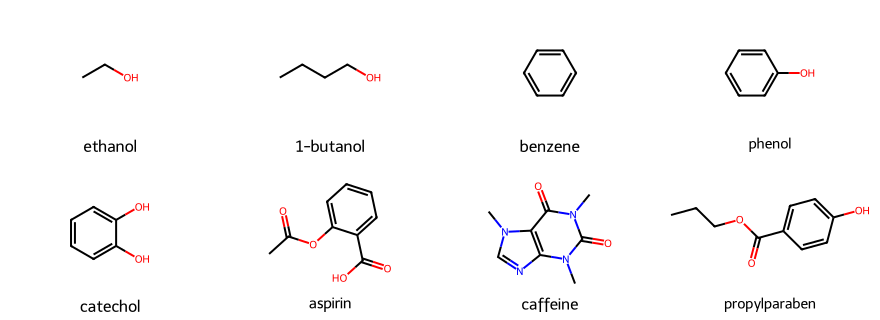

,name,MolLogP,TPSA,HBD,HBA,RotBonds
0,ethanol,-0.0014,20.23,1,1,0
1,1-butanol,0.7788,20.23,1,1,2
2,benzene,1.6866,0.00,0,0,0
3,phenol,1.3922,20.23,1,1,0
4,catechol,1.0978,40.46,2,2,0
5,aspirin,1.3101,63.60,1,3,2
6,caffeine,-1.0293,61.82,0,6,0
7,propylparaben,1.9590,46.53,1,3,3


In [88]:
samples = [
    ('ethanol',       'CCO'),
    ('1-butanol',     'CCCCO'),
    ('benzene',       'c1ccccc1'),
    ('phenol',        'Oc1ccccc1'),
    ('catechol',      'Oc1ccccc1O'),
    ('aspirin',       'CC(=O)Oc1ccccc1C(=O)O'),
    ('caffeine',      'Cn1c(=O)c2c(ncn2C)n(C)c1=O'),
    ('propylparaben', 'CCCOC(=O)c1ccc(O)cc1'),
]

rows = []
molecules = []
for name, smi in samples:
    mol = Chem.MolFromSmiles(smi)
    molecules.append(mol)
    rows.append({
        'name': name, 
        #'SMILES': smi,
        'MolLogP': round(Crippen.MolLogP(mol), 4),
        'TPSA': round(Descriptors.TPSA(mol), 2),
        'HBD': Descriptors.NumHDonors(mol),
        'HBA': Descriptors.NumHAcceptors(mol),
        'RotBonds': Descriptors.NumRotatableBonds(mol),
    })

display(Draw.MolsToGridImage(molecules, legends=[name for name, _ in samples], molsPerRow=4, subImgSize=(220, 160)))

table = pd.DataFrame(rows)
display(table)

> 다시 jupyter Notebook으로 돌아가자.

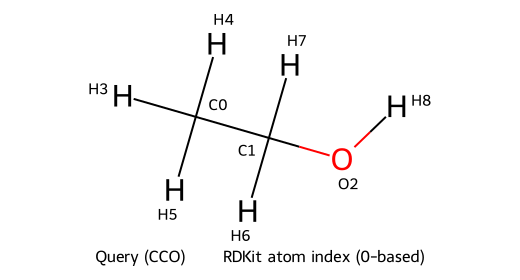

,atom,idx,logP_contrib
0,C,0,0.1441
1,C,1,-0.2035
2,O,2,-0.2893
3,H,3,0.1230
4,H,4,0.1230
5,H,5,0.1230
6,H,6,0.1230
7,H,7,0.1230
8,H,8,-0.2677


원자별 기여도 합계: -0.0014
Crippen MolLogP:     -0.0014


In [106]:
# 원자별 Crippen LogP 기여도 시각화 및 표 생성
def show_crippen_atom_contributions(smiles='CCO', name=''):
    """원자 인덱스 구조, Crippen LogP 기여도 표, 기여도 합계를 출력한다."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f'유효하지 않은 SMILES입니다: {smiles}')

    mol_h = Chem.AddHs(mol)
    contribs = rdMolDescriptors._CalcCrippenContribs(mol_h)

    # 표의 idx와 구조 속 원자를 연결할 수 있도록 표시용 복사본에 인덱스를 붙인다.
    indexed_mol = Chem.Mol(mol_h)
    for atom in indexed_mol.GetAtoms():
        atom.SetProp("atomNote", f"{atom.GetSymbol()}{atom.GetIdx()}")

    display(Draw.MolToImage(
        indexed_mol,
        size=(520, 280),
        legend=f'{name} ({smiles}) · RDKit atom index (0-based)'
    ))

    atom_table = pd.DataFrame([
        {
            'atom': atom.GetSymbol(),
            'idx': atom.GetIdx(),
            'logP_contrib': round(contribs[atom.GetIdx()][0], 4),
        }
        for atom in mol_h.GetAtoms()
    ])
    display(atom_table)

    print(colored('원자별 기여도 합계: ', 'blue') + colored(f'{sum(value[0] for value in contribs):.4f}', 'green'))
    print(colored('Crippen MolLogP:     ', 'blue') + colored(f'{Crippen.MolLogP(mol):.4f}', 'green'))

    return atom_table
smiles = 'CCO'  # 에탄올
table = show_crippen_atom_contributions(smiles, 'Query')

> 다시 강의 자료로 돌아가보자.

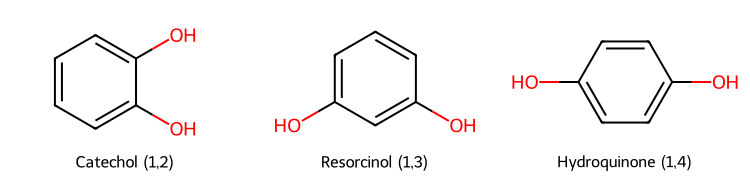

Catechol (1,2)            MolLogP = 1.0978
Resorcinol (1,3)          MolLogP = 1.0978
Hydroquinone (1,4)        MolLogP = 1.0978


In [113]:
isomers = [
    ('Catechol (1,2)',     'Oc1ccccc1O'),
    ('Resorcinol (1,3)',   'Oc1cccc(O)c1'),
    ('Hydroquinone (1,4)', 'Oc1ccc(O)cc1'),
]

# 🖼️ 세 위치이성질체의 2D 구조를 나란히 표시
display(Draw.MolsToGridImage(
    [Chem.MolFromSmiles(s) for _, s in isomers],
    legends=[name for name, _ in isomers],
    subImgSize=(250, 180),
    molsPerRow=3
))

for name, smi in isomers:
    mol = Chem.MolFromSmiles(smi)
    logp = Crippen.MolLogP(mol)
    print(f'{name:25s} MolLogP = {logp:.4f}')

> AI에게 "Cyclosporin A의 LogP는?"이라고 물었을 때,  
> AI는 답변 속 LogP의 값이 **어떤 모델의 계산값인지** 구분해서 말해줄 수 있을까? 
> 아니면 RDKit, Crippen 모델로 계산해놓고 아무런 정보도 주지 않았을까?

## 이제는 TPSA를 한번 알아보자

### TPSA의 한계도 확인해보자

에탄올과 2,2,2-트리플루오로에탄올의 2D 구조와 TPSA를 비교해보자.

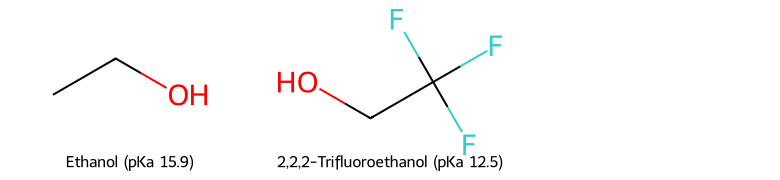

Ethanol                         TPSA = 20.23 Å²   MolLogP = -0.0014
2,2,2-Trifluoroethanol          TPSA = 20.23 Å²   MolLogP = 0.5410


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [ ]:
display(Draw.MolsToGridImage(
    [Chem.MolFromSmiles('CCO'), Chem.MolFromSmiles('FC(F)(F)CO')],
    legends=['Ethanol (pKa 15.9)', '2,2,2-Trifluoroethanol (pKa 12.5)'],
    subImgSize=(260, 180)
))

for name, smi in [('Ethanol', 'CCO'), ('2,2,2-Trifluoroethanol', 'FC(F)(F)CO')]:
    mol = Chem.MolFromSmiles(smi)
    tpsa = Descriptors.TPSA(mol)
    logp = Crippen.MolLogP(mol)
    print(f'{name:30s}  TPSA = {tpsa:.2f} Å²   MolLogP = {logp:.4f}')

def show_3d_surface_comparison(molecule_specs, max_tpsa_contrib=20.23):
    """원자별 TPSA 기여도를 VDW 표면에 매핑하여 나란히 표시한다."""
    view = py3Dmol.view(
        width=920,
        height=360,
        viewergrid=(1, len(molecule_specs)),
        linked=False,
    )

    for column, (name, smi) in enumerate(molecule_specs):
        mol_3d = Chem.AddHs(Chem.MolFromSmiles(smi))
        params = AllChem.ETKDGv3()
        params.randomSeed = 2026
        if AllChem.EmbedMolecule(mol_3d, params) != 0:
            raise RuntimeError(f'3D conformer 생성 실패: {name}')
        AllChem.MMFFOptimizeMolecule(mol_3d)
        tpsa_contribs = rdMolDescriptors._CalcTPSAContribs(mol_3d)
        conformer = mol_3d.GetConformer()
        xyz = [conformer.GetAtomPosition(i) for i in range(mol_3d.GetNumAtoms())]
        center_x = sum(point.x for point in xyz) / len(xyz)
        center_z = sum(point.z for point in xyz) / len(xyz)
        title_position = {'x': center_x, 'y': max(point.y for point in xyz) + 1.1, 'z': center_z}
        legend_position = {'x': center_x, 'y': min(point.y for point in xyz) - 1.1, 'z': center_z}
        tpsa_properties = [
            {
                'index': atom.GetIdx(),
                'props': {'tpsaContrib': float(tpsa_contribs[atom.GetIdx()])},
            }
            for atom in mol_3d.GetAtoms()
        ]

        view.addModel(Chem.MolToMolBlock(mol_3d), 'mol', viewer=(0, column))
        view.mapAtomProperties(
            tpsa_properties,
            {'model': 0},
            viewer=(0, column),
        )
        view.setStyle(
            {'model': 0},
            {'stick': {'colorscheme': 'Jmol', 'radius': 0.14}},
            viewer=(0, column),
        )
        view.addSurface(
            py3Dmol.VDW,
            {
                'opacity': 0.78,
                'colorscheme': {
                    'prop': 'tpsaContrib',
                    'gradient': 'linear',
                    'colors': ['#e2e8f0', '#99f6e4', '#0f766e'],
                    'min': 0.0,
                    'max': max_tpsa_contrib,
                },
            },
            {'model': 0},
            viewer=(0, column),
        )
        view.zoomTo({'model': 0}, viewer=(0, column))

    view.setBackgroundColor('#f8fafc')
    display(view)

show_3d_surface_comparison([
    ('Ethanol', 'CCO'),
    ('2,2,2-Trifluoroethanol', 'FC(F)(F)CO'),
])

## Conformer — 같은 분자, 다른 모양 (W3-06)

분자는 결합각과 단일결합 회전에 따라 여러 입체 배치를 가질 수 있다.  
아래에서는 **SMILES 한 줄을 직접 바꾸면서** 분자가 얼마나 크게 펄럭이는지 비교한다.

In [122]:
def show_3d(mol, conf_id=0, width=550, height=400):
    view = py3Dmol.view(width=width, height=height)
    mb = Chem.MolToMolBlock(mol, confId=conf_id)
    view.addModel(mb, 'mol')
    view.setStyle({'stick': {'colorscheme': 'Jmol'}})
    view.setBackgroundColor('#f8fafc')
    view.zoomTo()
    return view

def show_3d_overlay(mol, conf_ids=None, width=600, height=450):
    if conf_ids is None:
        conf_ids = [c.GetId() for c in mol.GetConformers()]
    view = py3Dmol.view(width=width, height=height)
    colors = ['#3b82f6', '#ef4444', '#22c55e', '#f59e0b',
              '#8b5cf6', '#ec4899', '#06b6d4', '#f97316']
    for i, cid in enumerate(conf_ids):
        mb = Chem.MolToMolBlock(mol, confId=cid)
        view.addModel(mb, 'mol')
        view.setStyle({'model': i}, {'stick': {'color': colors[i % len(colors)]}})
    view.setBackgroundColor('#f8fafc')
    view.zoomTo()
    return view

def make_conformers(smiles, num_confs=8, seed=42, optimize=False):
    """SMILES에서 여러 conformer를 만들고, 필요하면 에너지를 최소화한다."""
    base = Chem.MolFromSmiles(smiles)
    if base is None:
        raise ValueError(f'SMILES를 읽을 수 없습니다: {smiles}')

    mol = Chem.AddHs(base)
    params = AllChem.ETKDGv3()
    params.randomSeed = seed
    conf_ids = list(AllChem.EmbedMultipleConfs(mol, numConfs=num_confs, params=params))
    if not conf_ids:
        raise RuntimeError('Conformer 생성에 실패했습니다.')

    if optimize:
        AllChem.MMFFOptimizeMoleculeConfs(mol, numThreads=1, maxIters=500)

    rdMolAlign.AlignMolConformers(mol)
    print(f'SMILES: {smiles}')
    print(f'회전 가능한 결합: {Descriptors.NumRotatableBonds(base)}개')
    print(f'생성된 conformer: {len(conf_ids)}개')
    print(f'에너지 최소화: {"실행" if optimize else "실행하지 않음"}')
    return mol

### 🔬 가장 중요한 실습: `MY_SMILES`를 직접 바꿔보자

먼저 짧은 사슬로 실행하고, C를 늘리거나 고리 구조를 입력해 결과를 비교한다.

In [148]:
MY_SMILES = 'CC=CC'  # ← 따옴표 안을 직접 바꿔보자

my_mol = make_conformers(MY_SMILES, num_confs=8, seed=42, optimize=False)
show_3d_overlay(my_mol)

SMILES: CC=CC
회전 가능한 결합: 0개
생성된 conformer: 8개
에너지 최소화: 실행하지 않음


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### 예시 1 · 단단한 고리와 곁사슬을 비교해보자

In [131]:
for name, smiles in [
    ('Benzene', 'c1ccccc1'),
    ('Propylparaben', 'CCCOC(=O)c1ccc(O)cc1'),
]:
    print(f'\n--- {name} ---')
    example_mol = make_conformers(smiles, num_confs=8, seed=42)
    display(show_3d_overlay(example_mol, width=520, height=350))


--- Benzene ---
SMILES: c1ccccc1
회전 가능한 결합: 0개
생성된 conformer: 8개
에너지 최소화: 실행하지 않음


3Dmol.js failed to load for some reason. Please check your browser console for error messages.


--- Propylparaben ---
SMILES: CCCOC(=O)c1ccc(O)cc1
회전 가능한 결합: 3개
생성된 conformer: 8개
에너지 최소화: 실행하지 않음


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### 예시 2 · 긴 사슬은 얼마나 크게 펄럭일까?

In [145]:
palmitic = make_conformers(
    'CCCCCCCCCCCCCCC(=O)O',
    num_confs=8,
    seed=42,
    optimize=False,
)
show_3d_overlay(palmitic)

SMILES: CCCCCCCCCCCCCCC(=O)O
회전 가능한 결합: 13개
생성된 conformer: 8개
에너지 최소화: 실행하지 않음


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## 에너지 최소화 — 어색한 구조를 조금 다듬기

생성된 conformer를 토대로, 결합 길이·결합각과 원자 사이 거리가 조금 더 자연스러워지도록 에너지를 낮춰볼 수 있다!

In [133]:
ENERGY_SMILES = MY_SMILES  # ← 여기에도 원하는 SMILES를 넣어보자
before_mol = make_conformers(ENERGY_SMILES, num_confs=8, seed=42, optimize=False)
opt_mol = Chem.Mol(before_mol)
results = AllChem.MMFFOptimizeMoleculeConfs(opt_mol, numThreads=1, maxIters=1000)
rdMolAlign.AlignMolConformers(opt_mol)

energy_rows = []
for i, (converged, energy) in enumerate(results):
    ff_before = AllChem.MMFFGetMoleculeForceField(before_mol, AllChem.MMFFGetMoleculeProperties(before_mol), confId=i)
    e_before = ff_before.CalcEnergy()
    energy_rows.append({'conf_id': i, 'E_before': round(e_before, 2), 'E_after': round(energy, 2),
                        'converged': converged == 0, 'ΔE': round(energy - e_before, 2)})

e_df = pd.DataFrame(energy_rows)
display(e_df)
print(f'\n에너지가 가장 낮은 conformer: conf_id = {e_df.loc[e_df.E_after.idxmin(), "conf_id"]}')

SMILES: CCCOCCC
회전 가능한 결합: 4개
생성된 conformer: 8개
에너지 최소화: 실행하지 않음


,conf_id,E_before,E_after,converged,ΔE
0,0,12.27,1.20,True,-11.07
1,1,22.49,2.82,True,-19.66
2,2,16.25,2.58,True,-13.66
3,3,15.16,2.78,True,-12.38
4,4,17.10,1.40,True,-15.71
5,5,20.26,2.67,True,-17.59
6,6,21.11,1.20,True,-19.91
7,7,17.70,2.78,True,-14.91



에너지가 가장 낮은 conformer: conf_id = 0


### 🧊 최소화 전후 비교 — 3D로 확인

In [134]:
print('최소화 전: 여러 conformer')
display(show_3d_overlay(before_mol, width=700, height=420))

print('최소화 후: 에너지는 낮아졌지만 conformer는 여전히 여러 모양')
display(show_3d_overlay(opt_mol, width=700, height=420))

best_id = int(e_df.loc[e_df.E_after.idxmin(), 'conf_id'])
print(f'이번 후보 중 에너지가 가장 낮은 conformer: {best_id}')
print('※ 가장 낮은 후보 하나가 실제 환경의 유일한 구조라는 뜻은 아니다.')

최소화 전: 여러 conformer


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

최소화 후: 에너지는 낮아졌지만 conformer는 여전히 여러 모양


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

이번 후보 중 에너지가 가장 낮은 conformer: 0
※ 가장 낮은 후보 하나가 실제 환경의 유일한 구조라는 뜻은 아니다.


## Conformer에 따라 달라지는 것

In [129]:
# 같은 palmitic acid의 여러 conformer에서 descriptor를 비교한다
def radius_of_gyration(mol, conf_id):
    conf = mol.GetConformer(conf_id)
    positions = conf.GetPositions()
    centroid = positions.mean(axis=0)
    return float(np.sqrt(((positions - centroid) ** 2).sum(axis=1).mean()))

shape_rows = []
for c in opt_mol.GetConformers():
    cid = c.GetId()
    shape_rows.append({
        'conf_id': cid,
        'MolLogP': round(Crippen.MolLogP(opt_mol), 4),
        'TPSA': round(Descriptors.TPSA(opt_mol), 2),
        'Rg (Å)': round(radius_of_gyration(opt_mol, cid), 3),
    })

shape_df = pd.DataFrame(shape_rows)
display(shape_df)

print(f'\nMolLogP 범위: {shape_df.MolLogP.min()} ~ {shape_df.MolLogP.max()} → 동일')
print(f'TPSA 범위:    {shape_df.TPSA.min()} ~ {shape_df.TPSA.max()} → 동일')
print(f'Rg 범위:      {shape_df["Rg (Å)"].min():.3f} ~ {shape_df["Rg (Å)"].max():.3f} → 다름!')

,conf_id,MolLogP,TPSA,Rg (Å)
0,0,1.823,9.23,2.865
1,1,1.823,9.23,2.657
2,2,1.823,9.23,2.711
3,3,1.823,9.23,2.825
4,4,1.823,9.23,2.709
5,5,1.823,9.23,2.534
6,6,1.823,9.23,2.865
7,7,1.823,9.23,2.825



MolLogP 범위: 1.823 ~ 1.823 → 동일
TPSA 범위:    9.23 ~ 9.23 → 동일
Rg 범위:      2.534 ~ 2.865 → 다름!
